**Aspect-Based Sentiment Analysis (ABSA) - Text**

*імпорти*

In [1]:
#!pip install langdetect
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno
import re
import unicodedata as uni
import demoji
from spellchecker import SpellChecker
import nltk
import spacy
nltk.download('stopwords')
nltk.download('omw-1.4')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
from nltk.corpus import stopwords
from nltk import word_tokenize, sent_tokenize, pos_tag
from nltk.corpus import wordnet
from nltk.tokenize import TreebankWordTokenizer
from nltk.stem import WordNetLemmatizer
from langdetect import detect
import string
import gensim
from gensim import corpora
from gensim.models import LdaMulticore
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
from gensim.models import FastText
from tqdm import tqdm
import warnings
import torch
from torch.utils.data import Dataset
import pickle
import torch.nn as nn
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold
from torch.utils.data import SubsetRandomSampler
from torch.optim import Adam
from torch.utils.data import DataLoader
import numpy as np
import nltk
import ssl


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [2]:
stop_words = set(stopwords.words("english"))
punct = set(string.punctuation)
spell = SpellChecker()
cache = {}
lemmatizer = WordNetLemmatizer()
nlp = spacy.load("en_core_web_sm")
#stop_words = nlp.Defaults.stop_words

In [3]:
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download()

showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml


True

***1. Нормалізацнія текстy***

*видалення пyстих значень*

In [3]:
def remove_null(df):
    df = df.dropna(subset=["Review"])
    df = df[df["Review"].apply(lambda x: isinstance(x, str))]
    df.info()
    return df

*видалення URL адрес*

In [4]:
def remove_urls(text):
    if isinstance(text, str):
        return re.sub(r'http\S+|www\.\S+', '', text)
    return text

*визначення мови та виправлення змішуваного коду та транслітерацій*

In [5]:
def lg_detextion(text):
    lg = detect(text)
    print(f"{text} - {lg}")
    return lg

*нормалізація унікального тексту (зміна шрифту на стандартний та перетворення емодзі у текст)*

In [ ]:
def normalize_and_convert(text):
    new_text = uni.normalize('NFKD', text)# можна спробувати NFKC, який зберігає звичайні символи, а не в розкладеній версії, як робить це NFKD
    emojis = demoji.findall(new_text)

    for emoji, desc in emojis.items(): # цей спосіб сучасніше та читабільніше
       new_text = new_text.replace(emoji, " " + desc)

  #for emoji in emojis:
  #  text = text.replace(emoji, " " + emojis[emoji].split(":")[0])

    return new_text

*виправлення орфографічних помилок*

In [ ]:
def correct_text(text):
    words = text.split()
    corrected_words = []

    for word in words:
        if word in cache:
            corrected_words.append(cache[word])
            continue

        if word in spell:
            cache[word] = word
        else:
            corrected_word = spell.correction(word)
            cache[word] = corrected_word if corrected_word else word

        corrected_words.append(cache[word])
    return " ".join(corrected_words)

*токенізація слів, видалення стоп слів, лематизація*

In [ ]:
def preprocess_and_lemmatize_text(text):

    def get_wordnet_pos(tag):
        if tag.startswith("J"):
            return wordnet.ADJ
        elif tag.startswith("V"):
            return wordnet.VERB
        elif tag.startswith("N"):
            return wordnet.NOUN
        elif tag.startswith("R"):
            return wordnet.ADV
        return wordnet.NOUN

    sentences = sent_tokenize(text.lower())
    result = []

    for sentence in sentences:
        words = word_tokenize(sentence)

        # очищення
        words = [
            w for w in words 
            if w not in stop_words 
            and w not in punct 
            and not w.isdigit()
        ]

        pos_tags = pos_tag(words)

        # лематизація
        lemmas = [
            lemmatizer.lemmatize(w, get_wordnet_pos(tag)) 
            for w, tag in pos_tags
        ]

        # будуємо аспектні біграми: ADJ+NOUN або NOUN+ADJ
        for i in range(len(pos_tags) - 1):
            w1, t1 = lemmas[i], pos_tags[i][1]
            w2, t2 = lemmas[i+1], pos_tags[i+1][1]

            # adj + noun
            if t1.startswith("JJ") and t2.startswith("NN"):
                result.append(f"{w1} {w2}")

            # noun + adj
            elif t1.startswith("NN") and t2.startswith("JJ"):
                result.append(f"{w1} {w2}")

    return result

# старий варіант
# def preprocess_and_lemmatize_text(text):
    # new_text = text.lower()
    # words = tokenizer.tokenize(new_text)
    # words = [w for w in words if w not in stop_words and w not in punct]
    # lemmas = [lemmatizer.lemmatize(w) for w in words]
    # print(f"Старий текст - {text}")
    # print(f"Виправлений - {lemmas}")
    # return lemmas

In [8]:
def preprocess_and_lemmatize_text(text):

    def get_wordnet_pos(tag):
        return (
            wordnet.ADJ if tag.startswith("J") else
            wordnet.VERB if tag.startswith("V") else
            wordnet.NOUN if tag.startswith("N") else
            wordnet.ADV if tag.startswith("R") else wordnet.NOUN
        )

    sentences = sent_tokenize(text.lower())
    tokens = []
    aspects = []

    for sentence in sentences:
        words = word_tokenize(sentence)
        words = [w for w in words if w not in stop_words and w not in punct and not w.isdigit()]
        pos = pos_tag(words)
        lemmas = [lemmatizer.lemmatize(w, get_wordnet_pos(t)) for w, t in pos]

        tokens.extend(lemmas)  # ← для LDA

        for i in range(len(lemmas) - 1):
            if pos[i][1].startswith("JJ") and pos[i+1][1].startswith("NN"):
                aspects.append(f"{lemmas[i]} {lemmas[i+1]}")
            if pos[i][1].startswith("NN") and pos[i+1][1].startswith("JJ"):
                aspects.append(f"{lemmas[i]} {lemmas[i+1]}")

    return tokens, aspects


*графік пyстих значень*

In [9]:
def plt_null(df):
    plt.figure(figsize=(25, 20))
    msno.matrix(df, color=[0.2, 0.4, 1])
    plt.show()

*графік важливих ознак*

*реалізація очищенню тенкста*

In [10]:
def main(df):
    # перевірка даних на пyсті значення
    print("------------------------- 1. перевірка даних на пyсті значення -------------------------")
    if df.isnull().values.any():
            plt_null(df)
            df = remove_null(df)
            plt_null(df)

    df["Review"] = df["Review"].astype(str)
    print("------------------------- 2. видалення URL адрес -------------------------")
    df["Review"] = df["Review"].apply(remove_urls)
    print(df["Review"])

    print("------------------------- 3. нормалізація унікального тексту (зміна шрифту на стандартний та перетворення емодзі у текст) -------------------------")
    df["Review_cleaned"] = df["Review"].apply(normalize_and_convert)

    print(f"старий текст - {df["Review"]}")
    print(f"новий текст - {df["Review_cleaned"]}")

    print("------------------------- 4. виправлення орфографічних помилок -------------------------")
    df["Review_corrected"] = df["Review_cleaned"].apply(correct_text)

    print(f"старий текст - {df["Review_cleaned"]}")
    print(f"новий текст - {df["Review_corrected"]}")

    print("------------------------- 5. визначення мови та виправлення змішуваного коду та транслітерацій -------------------------")
    #df["language"] = df["Review_cleaned"].apply(
    #    lambda x: detect(x) if len(x.strip()) > 3 else "unknown"
    #)
    #print(f"{df["Review_cleaned"]} - {df["language"]}")
    
    df["language"] = df["Review_corrected"].apply(
        lambda x: detect(x) if len(x.strip()) > 3 else "unknown"
    )
    print(f"{df["Review_corrected"]} - {df["language"]}")

    print("------------------------- 6. токенізація слів, видалення стоп слів, лематизація -------------------------")
    df["tokens"], df["aspects"] = zip(*df["Review_corrected"].apply(preprocess_and_lemmatize_text))
    print(f"старий текст - {df["Review_corrected"]}")
    print(f"новий текст - {df["tokens"]}")
    print(f"новий текст - {df["aspects"]}")
    return df  

------------------------- 1. перевірка даних на пyсті значення -------------------------


<Figure size 2500x2000 with 0 Axes>

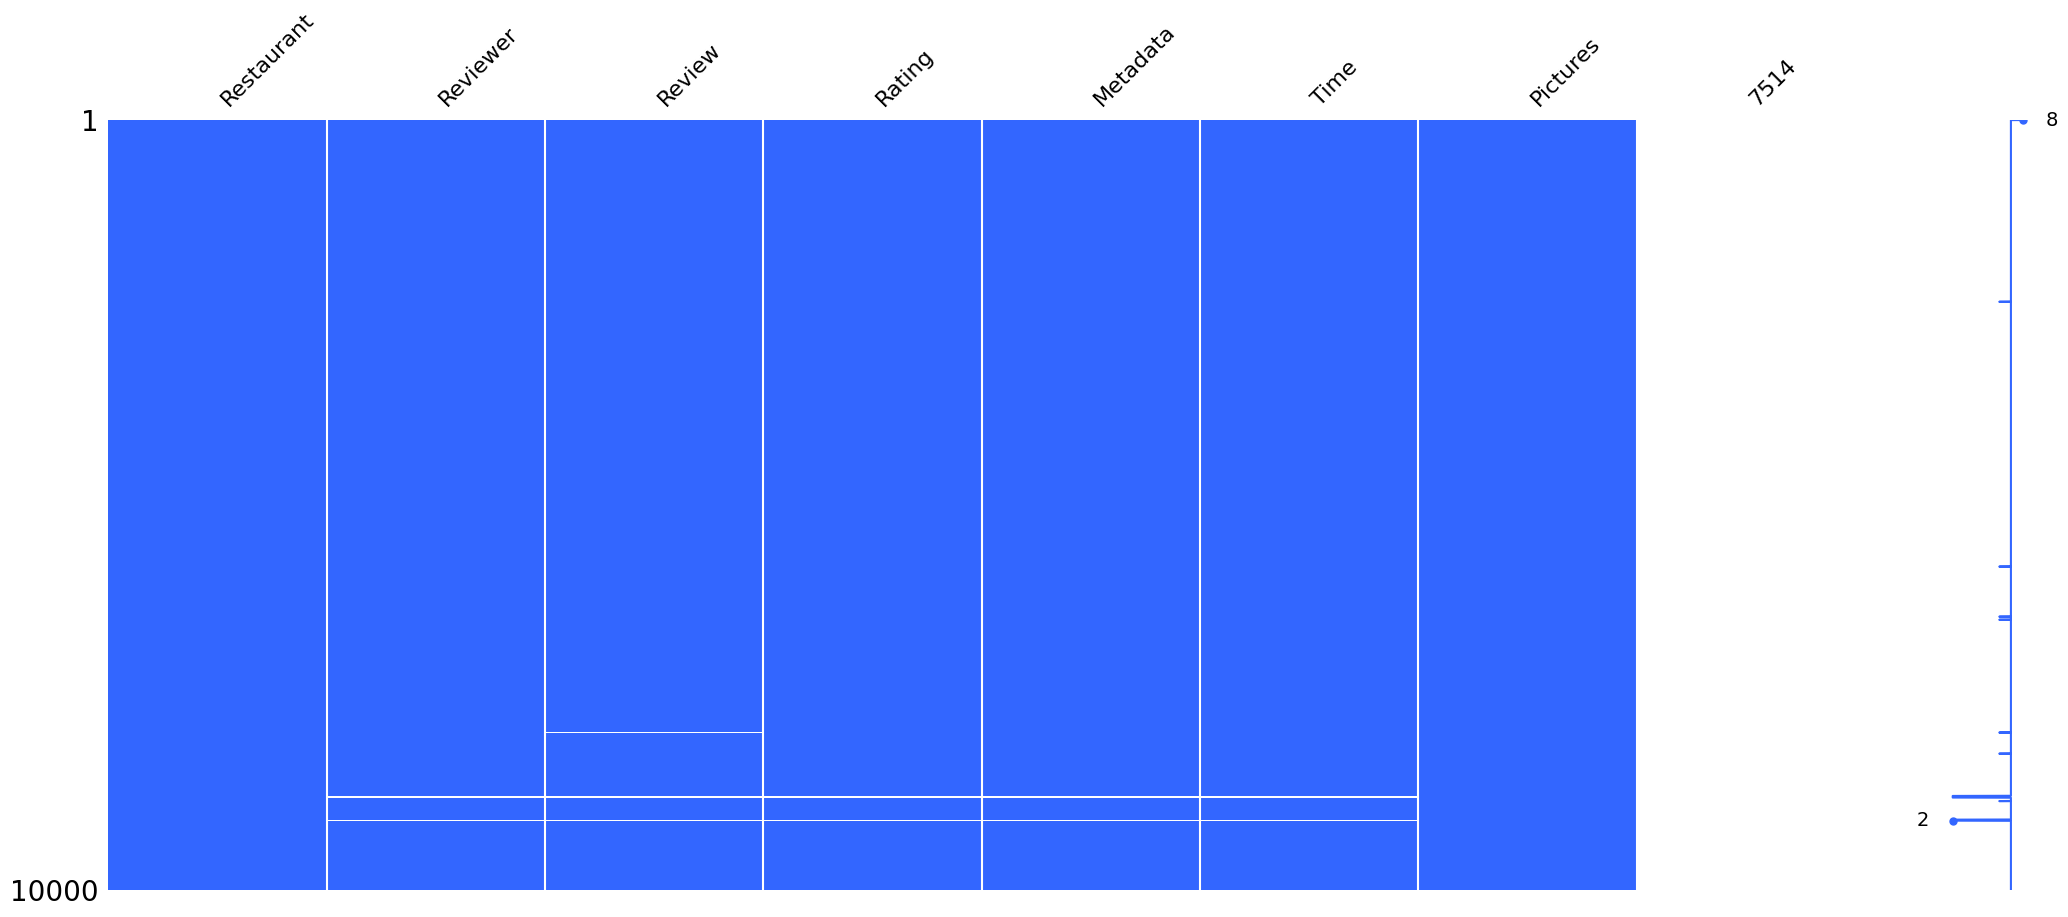

<class 'pandas.core.frame.DataFrame'>
Index: 9955 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Restaurant  9955 non-null   object 
 1   Reviewer    9955 non-null   object 
 2   Review      9955 non-null   object 
 3   Rating      9955 non-null   object 
 4   Metadata    9955 non-null   object 
 5   Time        9955 non-null   object 
 6   Pictures    9955 non-null   int64  
 7   7514        1 non-null      float64
dtypes: float64(1), int64(1), object(6)
memory usage: 700.0+ KB


<Figure size 2500x2000 with 0 Axes>

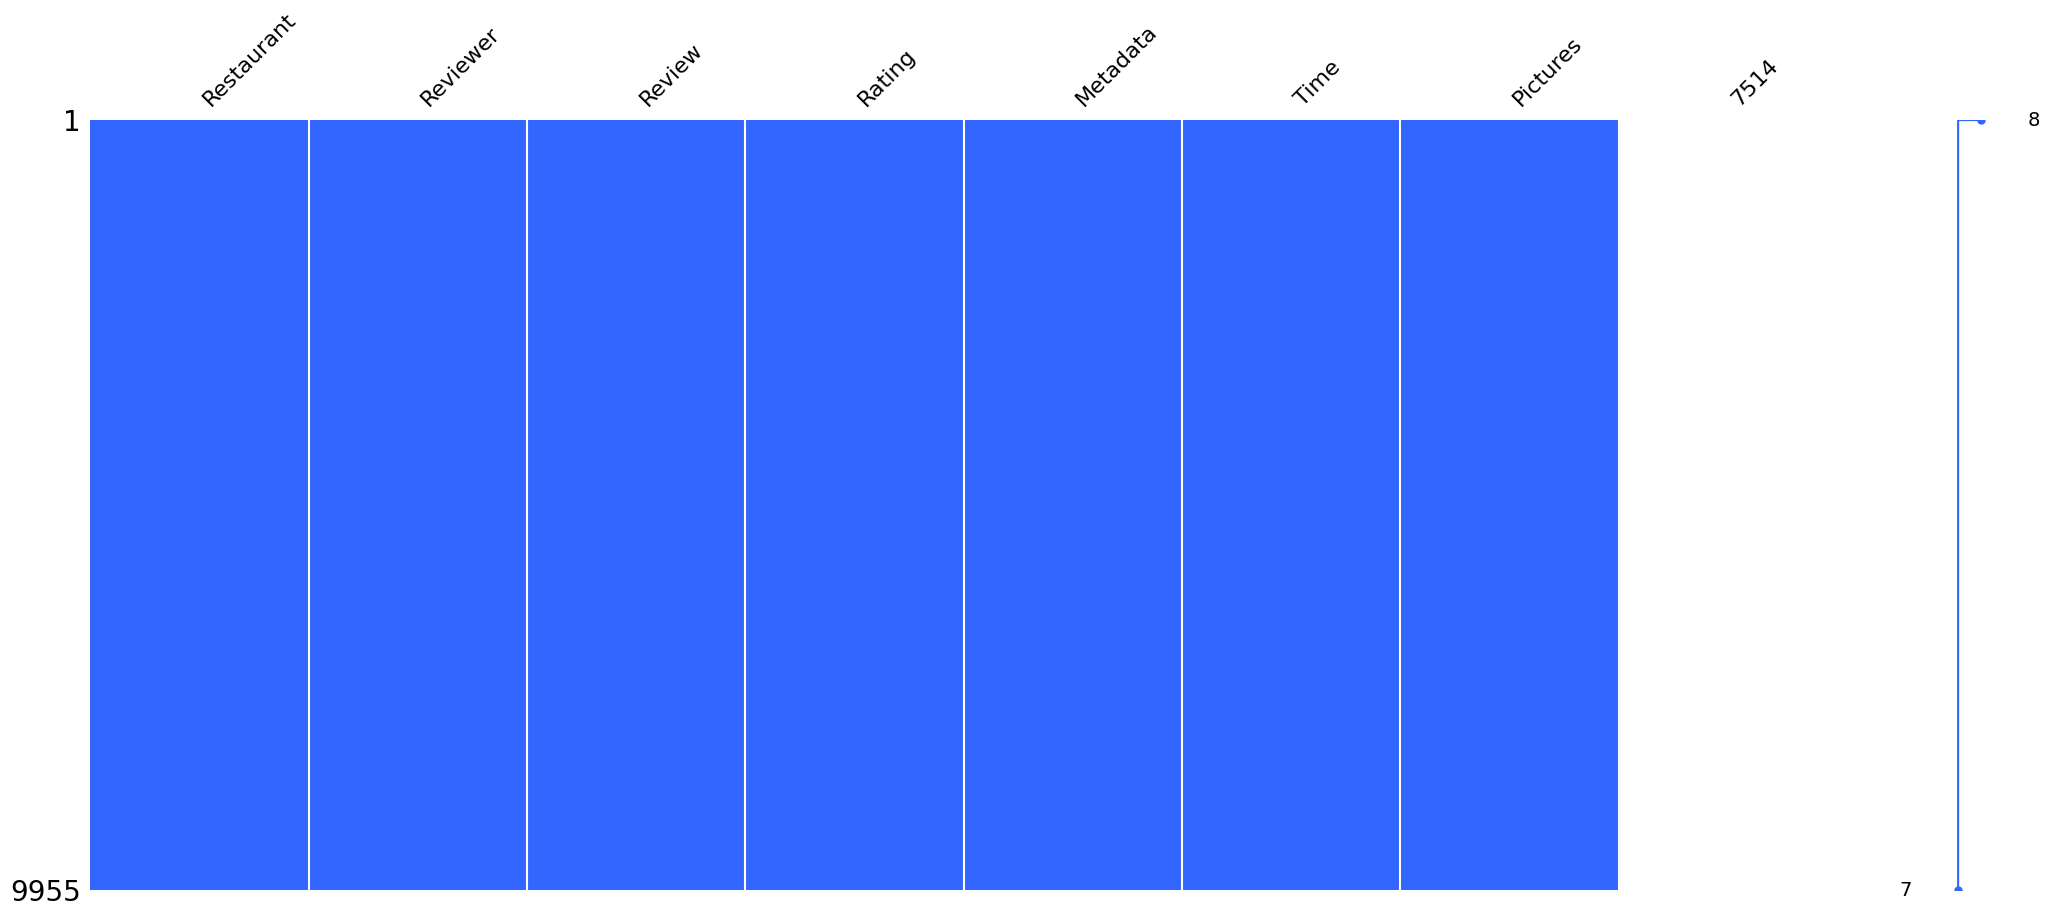

------------------------- 2. видалення URL адрес -------------------------
0       The ambience was good, food was quite good . h...
1       Ambience is too good for a pleasant evening. S...
2       A must try.. great food great ambience. Thnx f...
3       Soumen das and Arun was a great guy. Only beca...
4       Food is good.we ordered Kodi drumsticks and ba...
                              ...                        
9995    Madhumathi Mahajan Well to start with nice cou...
9996    This place has never disappointed us.. The foo...
9997    Bad rating is mainly because of "Chicken Bone ...
9998    I personally love and prefer Chinese Food. Had...
9999    Checked in here to try some delicious chinese ...
Name: Review, Length: 9955, dtype: object
------------------------- 3. нормалізація унікального тексту (зміна шрифту на стандартний та перетворення емодзі у текст) -------------------------
старий текст - 0       The ambience was good, food was quite good . h...
1       Ambience is too 

In [11]:
df = pd.read_csv("Restaurant_reviews.csv")
result = main(df)


result.to_csv("TextCleaner.csv", index=False, encoding='utf-8-sig')

d:\anaconda\Lib\site-packages\executing\executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
d:\anaconda\Lib\ast.py:602: DeprecationWarning: Constant.__init__ got an unexpected keyword argument 's'. Support for arbitrary keyword arguments is deprecated and will be removed in Python 3.15.
  return Constant(*args, **kwargs)
d:\anaconda\Lib\ast.py:602: DeprecationWarning: Attribute s is deprecated and will be removed in Python 3.14; use value instead
  return Constant(*args, **kwargs)
d:\anaconda\Lib\ast.py:602: DeprecationWarning: Constant.__init__ missing 1 required positional argument: 'value'. This will become an error in Python 3.15.
  return Constant(*args, **kwargs)
d:\anaconda\Lib\site-packages\executing\executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
d:\anaconda\Lib\ast.py:602: Deprec

KeyError: 'lemmas'

In [ ]:
class TextCleaner:
    def __init__(self):
        self.stop_words = set(stopwords.words("english"))
        self.punct = set(string.punctuation)
        self.spell = SpellChecker()
        self.cache = {}
        self.lemmatizer = WordNetLemmatizer()
    
    #
    def remove_null(df):
        df = df.dropna(subset=["Review"])
        df = df[df["Review"].apply(lambda x: isinstance(x, str))]
        df.info()
        return df
    
    #
    def remove_urls(self, text):
        return re.sub(r'http\S+|www\.\S+', '', text)
    
    #
    def normalize_and_convert(self, text):
        new = uni.normalize("NFKC", text)
        emojis = demoji.findall(new)
        for e, desc in emojis.items():
            new = new.replace(e, " " + desc)
        return new
    
    #
    def correct_text(self, text):
        words = text.split()
        corrected = []
        for w in words:
            if w in self.cache:
                corrected.append(self.cache[w])
                continue

            if w in self.spell:
                self.cache[w] = w
            else:
                fixed = self.spell.correction(w)
                self.cache[w] = fixed if fixed else w

            corrected.append(self.cache[w])
        return " ".join(corrected)
    
    #
    def get_pos(self, tag):
        if tag.startswith("J"): return wordnet.ADJ
        if tag.startswith("V"): return wordnet.VERB
        if tag.startswith("N"): return wordnet.NOUN
        if tag.startswith("R"): return wordnet.ADV
        return wordnet.NOUN
    
    #
    def lemmatize_text(self, text):
        sentences = sent_tokenize(text.lower())
        result = []

        for s in sentences:
            words = word_tokenize(s)
            words = [w for w in words if w not in self.stop_words and w not in self.punct]
            tags = pos_tag(words)
            lemmas = [self.lemmatizer.lemmatize(w, self.get_pos(t)) for w, t in tags]
            result.extend(lemmas)

        return result
    
    #
    def plt_null(df):
        plt.figure(figsize=(25, 20))
        msno.matrix(df, color=[0.2, 0.4, 1])
        plt.show()
    
    #
    def clean_dataframe(self, df):

        if df.isnull().values.any():
            plt_null(df)
            df = self.remove_null(df)
            plt_null(df)

        df["Review"] = df["Review"].astype(str)
        df["Review"] = df["Review"].apply(self.remove_urls)
        df["Review_cleaned"] = df["Review"].apply(self.normalize_and_convert)
        df["Review_corrected"] = df["Review_cleaned"].apply(self.correct_text)

        df["language"] = df["Review_corrected"].apply(
            lambda x: detect(x) if len(x.strip()) > 3 else "unknown"
        )

        df["lemmas"] = df["Review_corrected"].apply(self.lemmatize_text)

        return df
